## RDF analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
np.seterr(divide='ignore');
k = 1.380649e-23
T = 303.15

def plot_settings(title):
    plt.figure(figsize=(8,5))
    plt.grid()
    plt.tight_layout()
    plt.xlabel('Distance (nm)')
    plt.ylabel('g(r)')
    plt.title(f"{title}")

def plt_plot(name, label):
    data = np.loadtxt(f"{name}",skiprows=25)
    x = data[:, 0] 
    y = data[:, 1] 
    plt.plot(x,y,label = f"{label}")

def plt_plot_cn(name,name_cn, label):
    data = np.loadtxt(f"{name}",skiprows=25)
    x = data[:, 0] 
    y = data[:, 1] 
    plt.plot(x,y,label = f"{label}")
    data = np.loadtxt(f"{name_cn}",skiprows=25)
    x = data[:, 0] 
    y = data[:, 1] 
    plt.plot(x,y,label = f"{label}, cumulative", linestyle="dashed")

def find_min_max(run, run_cn): 
    data1 = np.loadtxt(f'{run}', skiprows=25)
    x1 = data1[:, 0] 
    y1 = data1[:, 1] 
    dy1 = np.gradient(y1, x1)
    
    minima_indices = np.where((dy1[:-1] < 0) & (dy1[1:] > 0))[0] + 1
    minima_x = x1[minima_indices]
    minima_y = y1[minima_indices]

    maxima_indices = np.where((dy1[:-1] > 0) & (dy1[1:] < 0))[0] + 1
    maxima_x = x1[maxima_indices]
    maxima_y = y1[maxima_indices]
    
    data2 = np.loadtxt(f'{run_cn}', skiprows=25)
    x2 = data2[:, 0] 
    y2 = data2[:, 1] 

    if minima_y.size > 0 and maxima_y.size > 0:
        smallest_min_index = np.argmin(minima_y)  
        largest_max_index = np.argmax(maxima_y)    
        
        smallest_min_x = minima_x[smallest_min_index]
        smallest_min_y = minima_y[smallest_min_index]
        
        largest_max_x = maxima_x[largest_max_index]
        largest_max_y = maxima_y[largest_max_index]

        cn_index = np.searchsorted(x2, smallest_min_x)  
        cn = y2[cn_index] if cn_index < len(y2) else None  

        print(f"Maximum found at r = {float(largest_max_x)} nm with g(r) = {float(largest_max_y)}")
        print(f"Minimum found at r = {float(smallest_min_x)} nm with g(r) = {float(smallest_min_y)}")
        print(f"Coordination number = {float(cn)}")

def pmf(file,label):
    data = np.loadtxt(file,skiprows=25)
    x = data[:, 0] 
    y = data[:, 1] 
    W = - k * T * np.log(y) / 4184 * 6.022e23
    plt.plot(x,W,label = label)

def hbonds(name, label): 
    data = np.loadtxt(f"{name}")
    x = data[:, 0] 
    y = data[:, 1] 
    avg = sum(y)/ (len(y)*31)
    print(f"Average number of H-bonds ({label}) = {avg}")

def occupancy(file,label):
    with open(f"{file}", 'r') as file:
        lines = file.readlines()
    
    occupancies = []
    for line in lines[2:]:  # Skip the first two lines
        parts = line.split()
        occupancy_str = parts[-1]  # The last part is the occupancy
        occupancy_value = float(occupancy_str.strip('%'))  # Convert to decimal
        occupancies.append(occupancy_value)
    
    average_occupancy = sum(occupancies) / len(occupancies)
    print(f"Average Occupancy ({label}): {average_occupancy}%")

## Testing of different charge distributions

| **Charge** | **N**       | **H**       | **Source**                                                                                     |
|------------|-------------|-------------|------------------------------------------------------------------------------------------------|
| charge0    | N: -0.33   | H: +0.33    | Original CHARMM parameters |
| charge1    | N: -0.40   | H: +0.35    | NH4+ partial charges using OPLS charges, as OPLS and CHARMM partial charges of N⁢H3+ in Lysine are nearly identical. [b]|
| charge2    | N: -0.625490| H: +0.406372| Partial charges were derived using electrostatic potential fitting. Energy constants were taken from the CHARMM, version 22, forcefield for primary amines. [h]|
| charge3    | N: -0.824  | H: +0.456   | Partial charges by restrained ESP-fit method using the ChlepG approach. [a]                    |

- 0.15 M NH4Cl (6 NH4, 6 Cl, 2022 TIP3P)
- 4-4-4 nm box
- 500 ns

### 1. Interaction with water

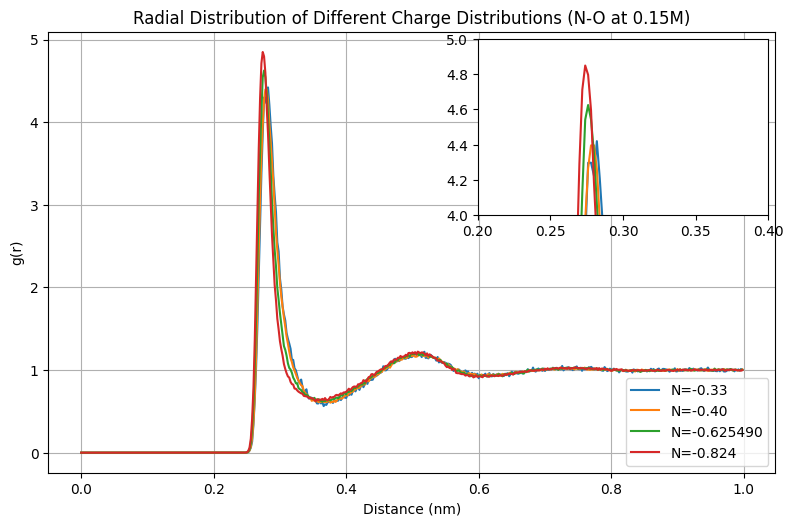

In [27]:
plot_settings("Radial Distribution of Different Charge Distributions (N-O at 0.15M)")
plt_plot('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33")
plt_plot('rdf/charge1/rdf_n-o.xvg', "N=-0.40")
plt_plot('rdf/charge2/rdf_n-o.xvg', "N=-0.625490")
plt_plot('rdf/charge3/rdf_n-o.xvg', "N=-0.824")
plt.legend(loc='lower right')

axins = inset_axes(plt.gca(), width="40%", height="40%", loc='upper right') 
axins.set_xlim(0.2, 0.4)  
axins.set_ylim(4, 5)      
for name, label in [('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33"),
                    ('rdf/charge1/rdf_n-o.xvg', "N=-0.40"),
                    ('rdf/charge2/rdf_n-o.xvg', "N=-0.625490"),
                    ('rdf/charge3/rdf_n-o.xvg', "N=-0.824")]:
    data = np.loadtxt(f"{name}", skiprows=25)
    x = data[:, 0]
    y = data[:, 1]
    axins.plot(x, y)  

plt.show()

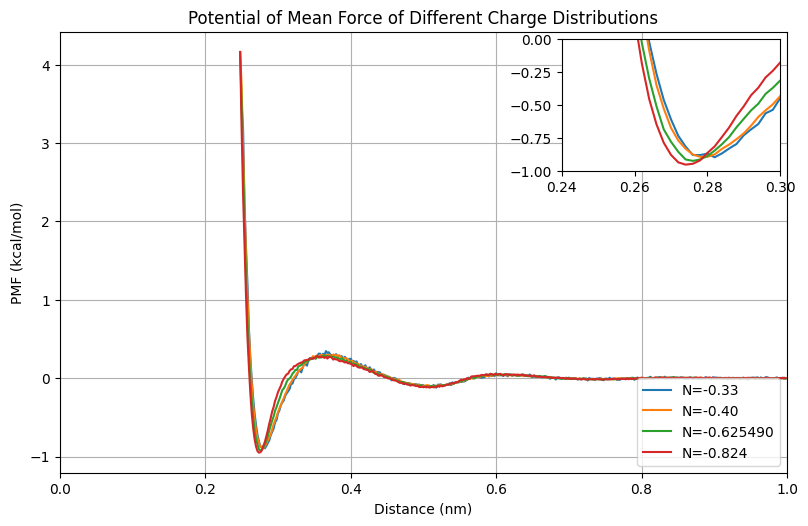

In [25]:
plot_settings("Potential of Mean Force of Different Charge Distributions")
plt.ylabel("PMF (kcal/mol)")
plt.xlim(0,1)
pmf('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33")
pmf('rdf/charge1/rdf_n-o.xvg', "N=-0.40")
pmf('rdf/charge2/rdf_n-o.xvg', "N=-0.625490")
pmf('rdf/charge3/rdf_n-o.xvg', "N=-0.824")
plt.legend(loc='lower right')
axins = inset_axes(plt.gca(), width="30%", height="30%", loc='upper right') 
axins.set_xlim(0.24, 0.3)  
axins.set_ylim(-1,0)   

for name, label in [('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33"),
                    ('rdf/charge1/rdf_n-o.xvg', "N=-0.40"),
                    ('rdf/charge2/rdf_n-o.xvg', "N=-0.625490"),
                    ('rdf/charge3/rdf_n-o.xvg', "N=-0.824")]:
    data = np.loadtxt(f"{name}", skiprows=25)
    x = data[:, 0]
    y = data[:, 1]
    W = - k * T * np.log(y) / 4184 * 6.022e23
    axins.plot(x, W)  
plt.show()

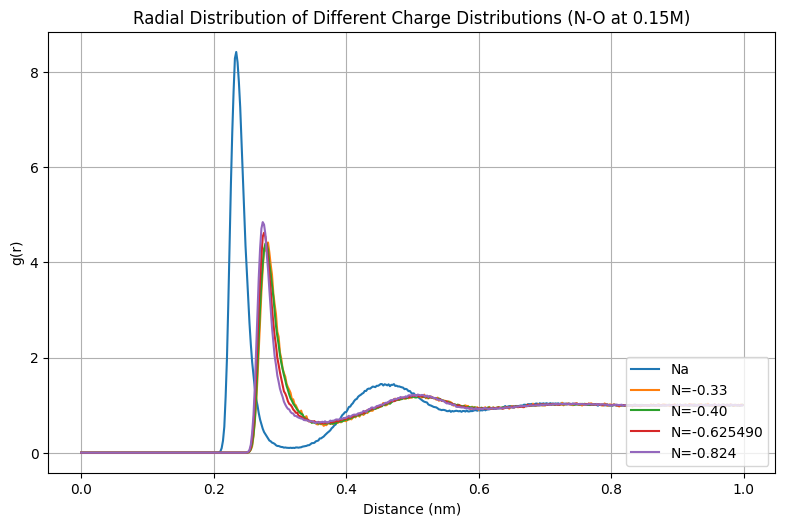

In [24]:
plot_settings("Radial Distribution of Different Charge Distributions (N-O at 0.15M)")
plt_plot('rdf/nacl-rdf/0.15M-run1-rdf/rdf_na-o.xvg', "Na")
plt_plot('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33")
plt_plot('rdf/charge1/rdf_n-o.xvg', "N=-0.40")
plt_plot('rdf/charge2/rdf_n-o.xvg', "N=-0.625490")
plt_plot('rdf/charge3/rdf_n-o.xvg', "N=-0.824")
plt.legend(loc='lower right')

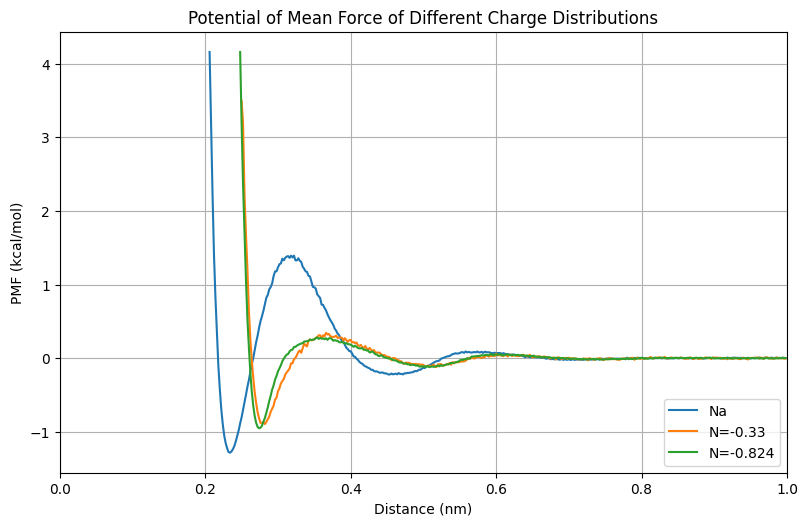

In [23]:
plot_settings("Potential of Mean Force of Different Charge Distributions")
plt.ylabel("PMF (kcal/mol)")
plt.xlim(0,1)
pmf('rdf/nacl-rdf/0.15M-run1-rdf/rdf_na-o.xvg', "Na")
pmf('rdf/nh4cl-rdf/rdf_0.15M-nh4-o.xvg', "N=-0.33")
pmf('rdf/charge3/rdf_n-o.xvg', "N=-0.824")
plt.legend(loc='lower right')

In [35]:
print("N-O RDF")
print("500ns__________________________")
print("charge0")
find_min_max('rdf/charge0/rdf_n-o.xvg','rdf/charge0/rdf_n-o_cn.xvg')
print("charge0, 1M")
find_min_max('rdf/charge0-1M/rdf_n-o.xvg','rdf/charge0-1M/rdf_n-o_cn.xvg')
print("charge1")
find_min_max('rdf/charge1/rdf_n-o.xvg','rdf/charge1/rdf_n-o_cn.xvg')
print("charge2")
find_min_max('rdf/charge2/rdf_n-o.xvg','rdf/charge2/rdf_n-o_cn.xvg')
print("charge3")
find_min_max('rdf/charge3/rdf_n-o.xvg','rdf/charge3/rdf_n-o_cn.xvg')

N-O RDF
500ns__________________________
charge0
Maximum found at r = 0.28 nm with g(r) = 4.376
Minimum found at r = 0.374 nm with g(r) = 0.604
Coordination number = 7.196
charge0, 1M
Maximum found at r = 0.282 nm with g(r) = 4.197
Minimum found at r = 0.366 nm with g(r) = 0.597
Coordination number = 6.488
charge1
Maximum found at r = 0.28 nm with g(r) = 4.397
Minimum found at r = 0.37 nm with g(r) = 0.611
Coordination number = 6.975
charge2
Maximum found at r = 0.278 nm with g(r) = 4.543
Minimum found at r = 0.364 nm with g(r) = 0.617
Coordination number = 6.528
charge3
Maximum found at r = 0.276 nm with g(r) = 4.796
Minimum found at r = 0.354 nm with g(r) = 0.625
Coordination number = 5.968


In [2]:
hbonds("hbonds/hbonds0.dat", "charge0")
hbonds("hbonds/hbonds1.dat", "charge1")
hbonds("hbonds/hbonds2.dat", "charge2")
hbonds("hbonds/hbonds3.dat", "charge3")

Average number of H-bonds (charge0) = 2.2515226708775096
Average number of H-bonds (charge1) = 2.344945377203442
Average number of H-bonds (charge2) = 2.613724984692727
Average number of H-bonds (charge3) = 2.822902903548065


### 2. Interaction with chloride 

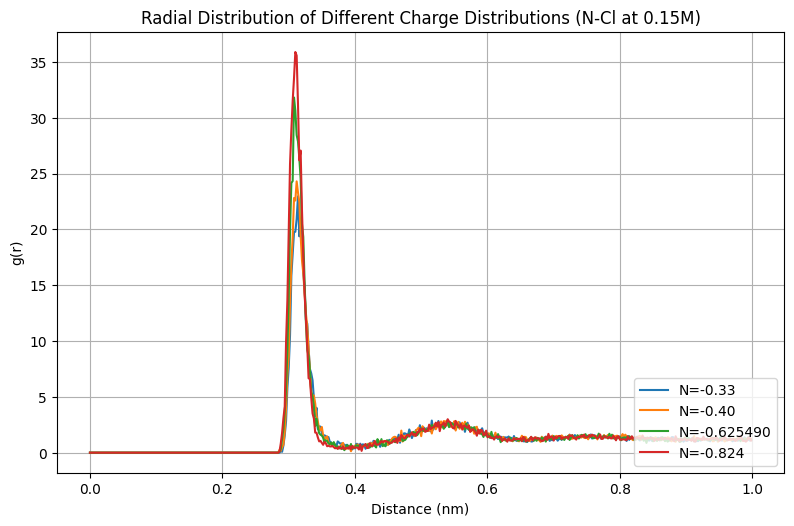

In [41]:
plot_settings("Radial Distribution of Different Charge Distributions (N-Cl at 0.15M)")
plt_plot('rdf/charge0/rdf_n-cl.xvg', "N=-0.33")
plt_plot('rdf/charge1/rdf_n-cl.xvg', "N=-0.40")
plt_plot('rdf/charge2/rdf_n-cl.xvg', "N=-0.625490")
plt_plot('rdf/charge3/rdf_n-cl.xvg', "N=-0.824")
plt.legend(loc='lower right')

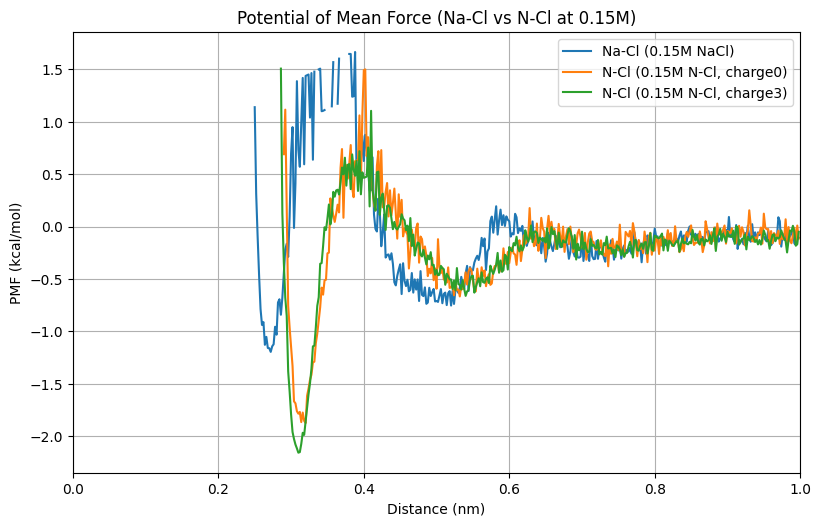

In [17]:
plot_settings("Potential of Mean Force (Na-Cl vs N-Cl at 0.15M)")
plt.ylabel("PMF (kcal/mol)")
plt.xlim(0,1)
pmf("rdf/nacl-rdf/0.15M-run1-rdf/rdf_na-cl.xvg","Na-Cl (0.15M NaCl)")
pmf("rdf/charge0/rdf_n-cl.xvg","N-Cl (0.15M N-Cl, charge0)")
pmf("rdf/charge3/rdf_n-cl.xvg","N-Cl (0.15M N-Cl, charge3)")
plt.legend()

In [34]:
print("N-Cl RDF")
print("charge0")
find_min_max('rdf/charge0/rdf_n-cl.xvg','rdf/charge0/rdf_n-cl_cn.xvg')
print("charge0, 1M")
find_min_max('rdf/charge0-1M/rdf_n-cl.xvg','rdf/charge0-1M/rdf_n-cl_cn.xvg')
print("charge1")
find_min_max('rdf/charge1/rdf_n-cl.xvg','rdf/charge1/rdf_n-cl_cn.xvg')
print("charge2")
find_min_max('rdf/charge2/rdf_n-cl.xvg','rdf/charge2/rdf_n-cl_cn.xvg')
print("charge3")
find_min_max('rdf/charge3/rdf_n-cl.xvg','rdf/charge3/rdf_n-cl_cn.xvg')

N-Cl RDF
charge0
Maximum found at r = 0.314 nm with g(r) = 22.967
Minimum found at r = 0.396 nm with g(r) = 0.3
Coordination number = 0.082
charge0, 1M
Maximum found at r = 0.314 nm with g(r) = 20.358
Minimum found at r = 0.394 nm with g(r) = 0.105
Coordination number = 0.429
charge1
Maximum found at r = 0.314 nm with g(r) = 23.311
Minimum found at r = 0.388 nm with g(r) = 0.402
Coordination number = 0.084
charge2
Maximum found at r = 0.31 nm with g(r) = 30.636
Minimum found at r = 0.384 nm with g(r) = 0.228
Coordination number = 0.097
charge3
Maximum found at r = 0.312 nm with g(r) = 35.571
Minimum found at r = 0.406 nm with g(r) = 0.286
Coordination number = 0.107


## 1. Na-Cl vs N-Cl

### RDF
$$ g(r) = \frac{<\rho (r)>}{\rho} $$
where g(r) is the radial distribtuion function, $<\rho (r)>$  is the average local number density of particles at a distance r, $\rho$ is the bulk density until r_max.

Average number of particles in the first shell $N = \int_V  4\pi r^2 \rho (r) dr$ 

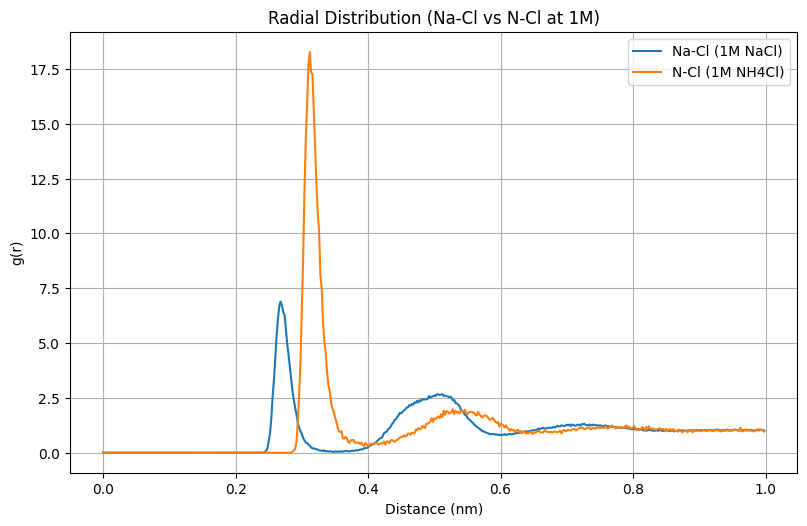

In [62]:
plot_settings("Radial Distribution (Na-Cl vs N-Cl at 1M)")
plt_plot('rdf/nacl-rdf/1M-run1-rdf/rdf_na-cl.xvg', "Na-Cl (1M NaCl)")
plt_plot('rdf/nh4cl-rdf/rdf_1M-nh4-cl.xvg', "N-Cl (1M NH4Cl)")
plt.legend()

### PMF 
$$ W(r) = -k_BT \ln(g(r)) $$
where W(r) is the pair potential, k_B is the Boltzmann constant, T is the temperature, and g(r) is the radial distribution function. 

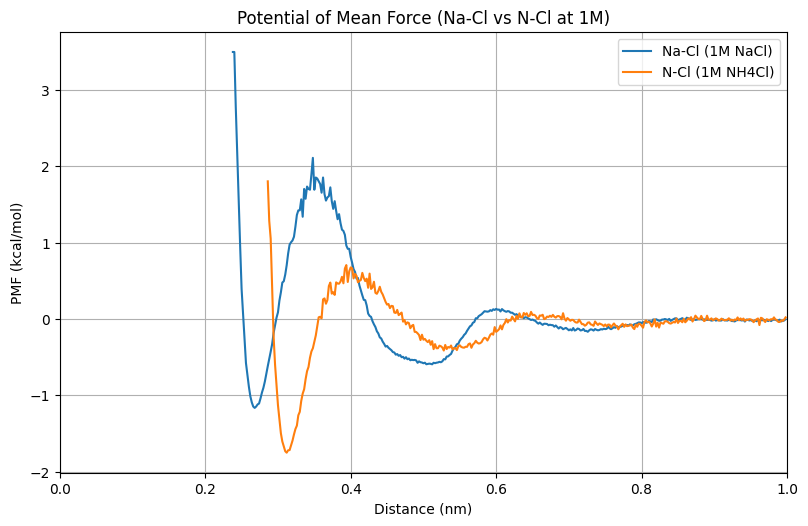

In [14]:
plot_settings("Potential of Mean Force (Na-Cl vs N-Cl at 1M)")
plt.ylabel("PMF (kcal/mol)")
plt.xlim(0,1)
pmf("rdf/nacl-rdf/1M-run1-rdf/rdf_na-cl.xvg","Na-Cl (1M NaCl)")
pmf("rdf/nh4cl-rdf/rdf_1M-nh4-cl.xvg","N-Cl (1M NH4Cl)")
plt.legend()

## 2. 1M NaCl

### 2a. Cl - H

First minimum found at: (0.292, 0.32253490525734063)nm


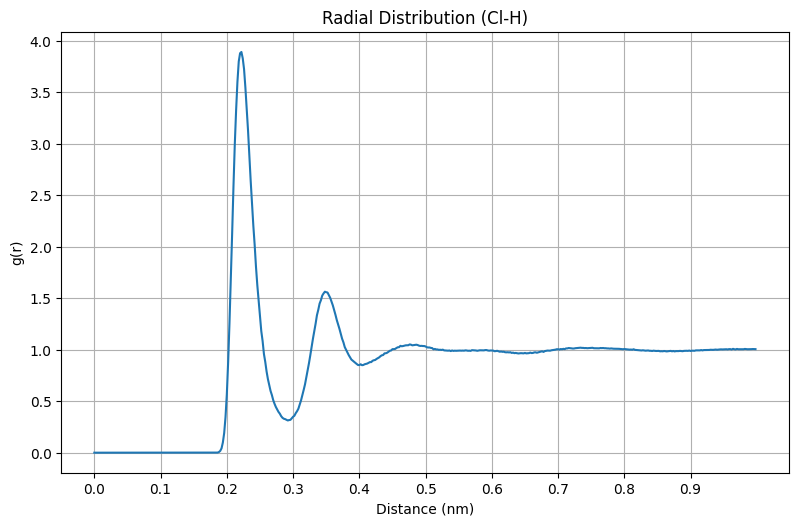

In [47]:
plot_settings("Radial Distribution (Cl-H)")
plt_plot("rdf/nacl-rdf/1M-run1-rdf/rdf_cl-h.xvg","Cl-H")
findminimum("rdf/nacl-rdf/1M-run1-rdf/rdf_cl-h.xvg")

### 2b. Cl - O

First maximum found at r = 0.316nm
First minimum found at r = 0.384nm
Coordination number = 7.911


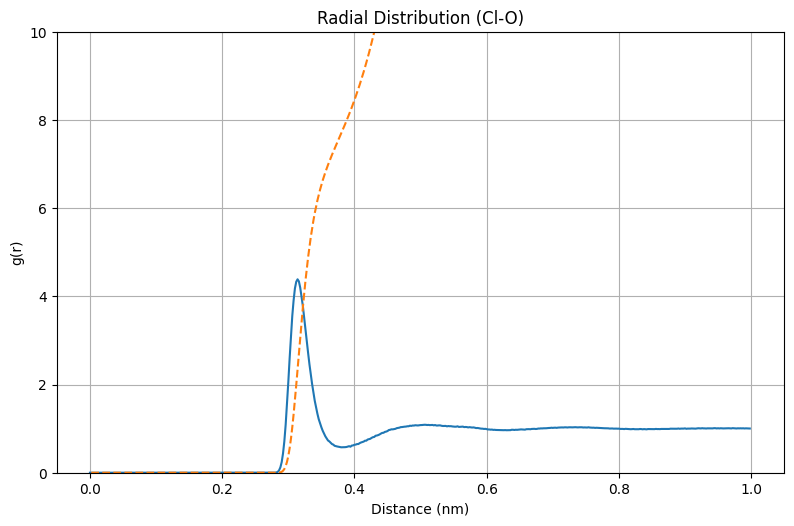

In [46]:
plot_settings("Radial Distribution (Cl-O)")
plt.ylim(0,10)
plt_plot("rdf/nacl-rdf/1M-run1-rdf/rdf_cl-o.xvg","Cl-O")
plt_plot_cn("rdf/nacl-rdf/1M-run1-rdf/rdf_cl-o_cn.xvg","Cl-O Cumulative")
findminimum("rdf/nacl-rdf/1M-run1-rdf/rdf_cl-o.xvg","rdf/nacl-rdf/1M-run1-rdf/rdf_cl-o_cn.xvg")

### 2c. Na - H

First minimum found at: (0.374, 0.4983458349419981)nm


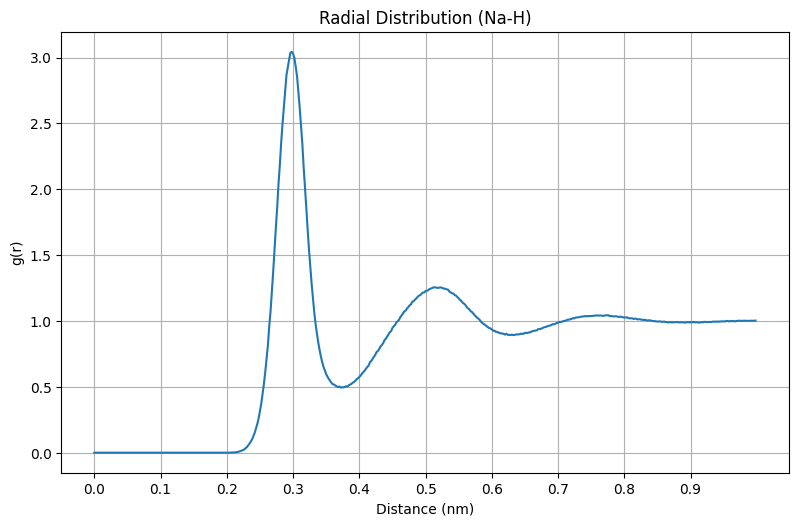

In [50]:
plot_settings("Radial Distribution (Na-H)")
plt_plot("rdf/nacl-rdf/1M-run1-rdf/rdf_na-h.xvg","Na-H")
findminimum("rdf/nacl-rdf/1M-run1-rdf/rdf_na-h.xvg")

### 2d. Na - O

First maximum found at r = 0.236nm
First minimum found at r = 0.318nm
Coordination number = 5.702


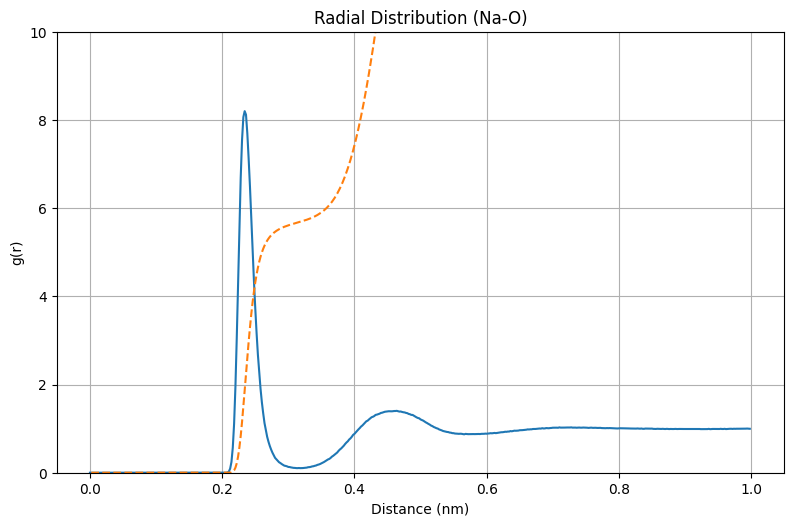

In [47]:
plot_settings("Radial Distribution (Na-O)")
plt.ylim(0,10)
plt_plot("rdf/nacl-rdf/1M-run1-rdf/rdf_na-o.xvg","Na-O")
plt_plot_cn("rdf/nacl-rdf/1M-run1-rdf/rdf_na-o_cn.xvg","Na-O Cumulative")
findminimum("rdf/nacl-rdf/1M-run1-rdf/rdf_na-o.xvg","rdf/nacl-rdf/1M-run1-rdf/rdf_na-o_cn.xvg")

## 3. 1M NH4Cl

### 3a. Cl - H

First minimum found at: (0.292, 0.30361514336567946)nm


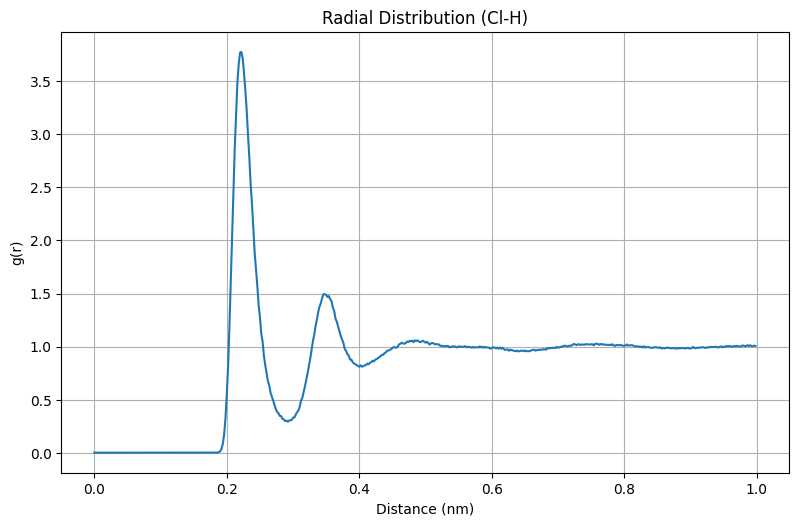

In [67]:
plot_settings("Radial Distribution (Cl-H)")
plt_plot("rdf/nh4cl-rdf/rdf_1M-cl-h.xvg","N-H")
findminimum('rdf/nh4cl-rdf/rdf_1M-cl-h.xvg')

### 3b. Cl - O

First maximum found at r = 0.316nm
First minimum found at r = 0.38nm
Coordination number = 7.227


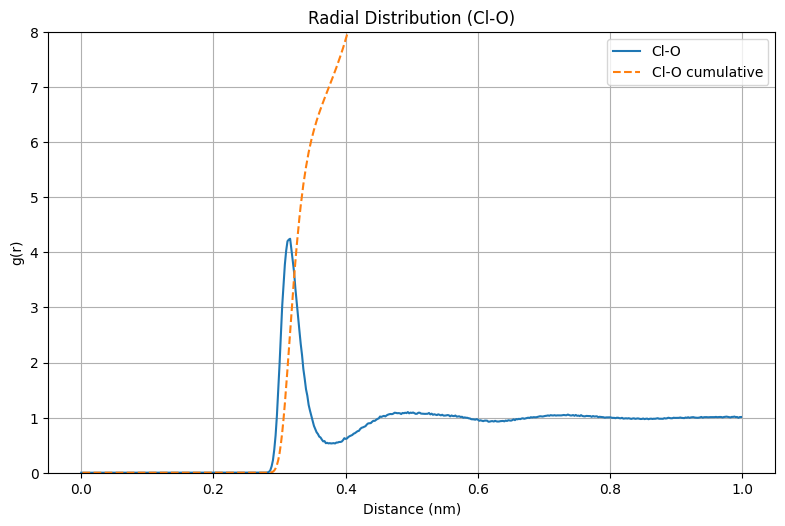

In [45]:
plot_settings("Radial Distribution (Cl-O)")
plt.ylim(0,8)
plt_plot("rdf/nh4cl-rdf/rdf_1M-cl-o.xvg","Cl-O")
plt_plot_cn("rdf/nh4cl-rdf/rdf_1M-cl-o_cn.xvg","Cl-O cumulative")
plt.legend()
findminimum('rdf/nh4cl-rdf/rdf_1M-cl-o.xvg','rdf/nh4cl-rdf/rdf_1M-cl-o_cn.xvg')

### 3c. N - H

First maximum found at r = 0.344nm
First minimum found at r = 0.438nm
Coordination number = 20.891


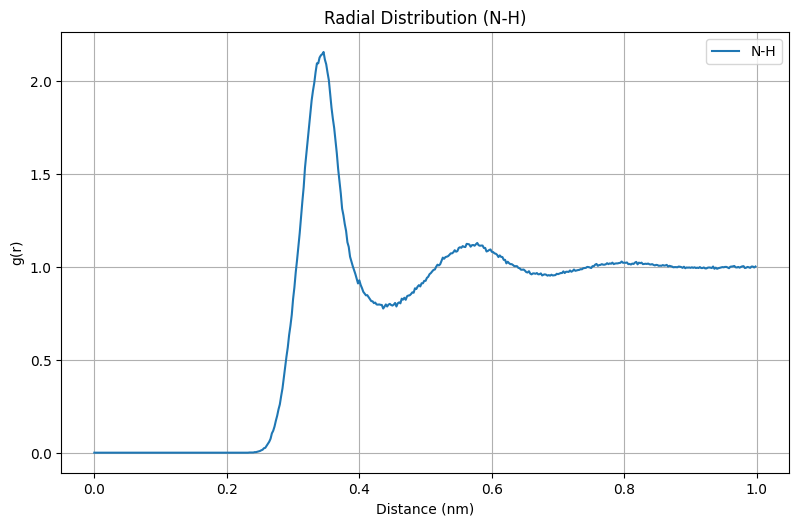

In [4]:
plot_settings("Radial Distribution (N-H)")
plt_plot("rdf/nh4cl-rdf/rdf_1M-nh4-h.xvg","N-H")
plt.legend()
findminimum('rdf/nh4cl-rdf/rdf_1M-nh4-h.xvg','rdf/nh4cl-rdf/rdf_1M-nh4-h_cn.xvg')

First maximum found at r = 0.344nm
First minimum found at r = 0.438nm
Coordination number = 0.201


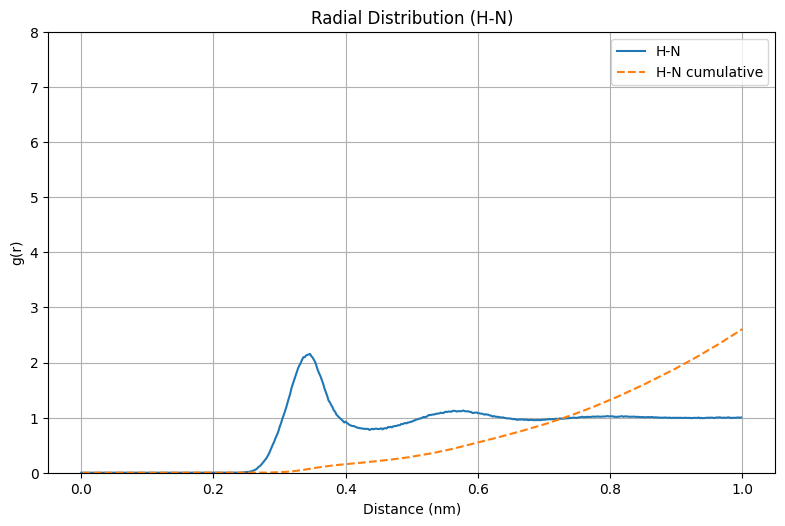

In [10]:
plot_settings("Radial Distribution (H-N)")
plt.ylim(0,8)
plt_plot("rdf/nh4cl-rdf/rdf_h-n.xvg","H-N")
plt_plot_cn("rdf/nh4cl-rdf/rdf_h-n_cn.xvg","H-N cumulative")
plt.legend()
findminimum('rdf/nh4cl-rdf/rdf_h-n.xvg',"rdf/nh4cl-rdf/rdf_h-n_cn.xvg")

### 3d. N - O

First maximum found at r = 0.282nm
First minimum found at r = 0.366nm
Coordination number = 6.581


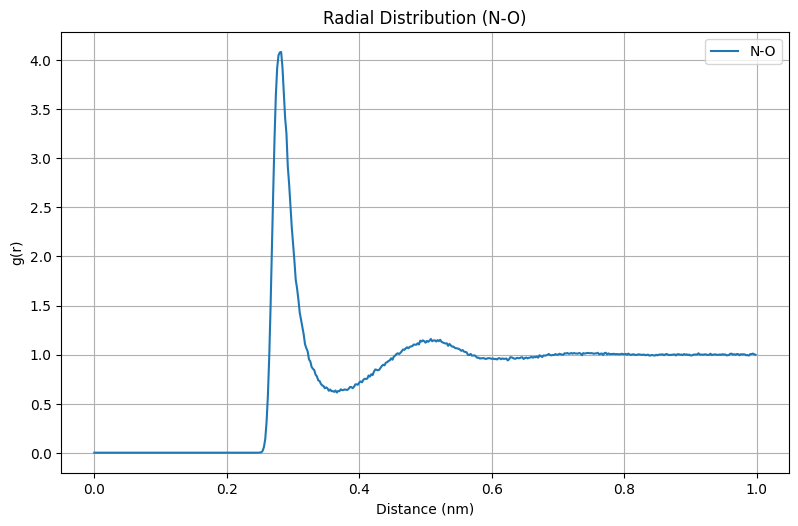

In [6]:
plot_settings("Radial Distribution (N-O)")
plt.ylim(0,8)
plt_plot("rdf/nh4cl-rdf/rdf_1M-nh4-o.xvg","N-O")
plt_plot_cn("rdf/nh4cl-rdf/rdf_1M-nh4-o_cn.xvg","N-O cumulative")
plt.legend()
findminimum('rdf/nh4cl-rdf/rdf_1M-nh4-o.xvg',"rdf/nh4cl-rdf/rdf_1M-nh4-o_cn.xvg")

First maximum found at r = 0.282nm
First minimum found at r = 0.366nm
Coordination number = 0.127


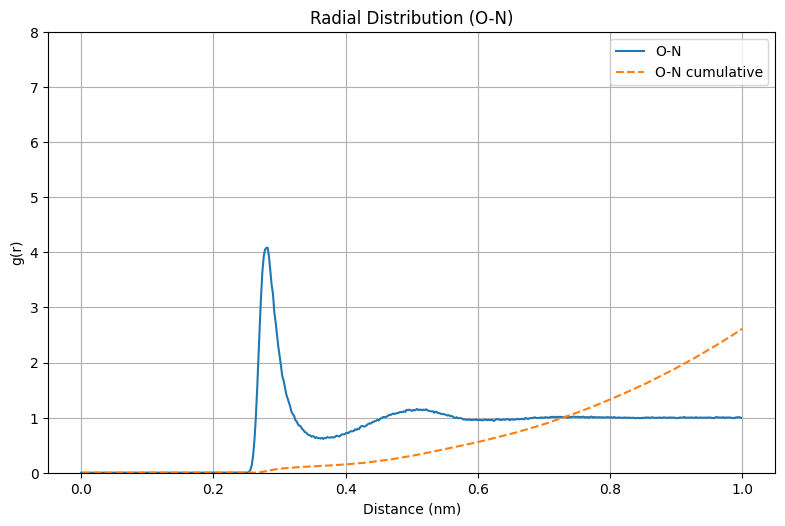

In [4]:
plot_settings("Radial Distribution (O-N)")
plt.ylim(0,8)
plt_plot("rdf/nh4cl-rdf/rdf_1M-o-n.xvg","O-N")
plt_plot_cn("rdf/nh4cl-rdf/rdf_1M-o-n_cn.xvg","O-N cumulative")
plt.legend()
findminimum('rdf/nh4cl-rdf/rdf_1M-o-n.xvg',"rdf/nh4cl-rdf/rdf_1M-o-n_cn.xvg")